In [1]:
from pathlib import Path

import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.cm as mcm
import matplotlib.ticker as mticker
import numpy as np
import pandas as pd
from matplotlib.gridspec import GridSpec
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
from shapely.geometry import box as shapely_box
from pyproj import Transformer

PM25_DIR   = Path("/Volumes/UCL/论文工作/空气污染/weighted_pm25/city_wgt_pm25")
DEATH_DIR  = Path("/Volumes/UCL/论文工作/空气污染/health_burden/air_scenarios_5")
OUTFILE    = Path("/Users/shirley/Desktop/plots_V2/Fig1_income.png")
SHP_PATH   = Path("/Users/shirley/Library/CloudStorage/OneDrive-UniversityCollegeLondon/Desktop/city_shp/shi_en.shp")
CHINA_SHP  = Path("/Users/shirley/Library/CloudStorage/OneDrive-UniversityCollegeLondon/Desktop/中国底图-中图社审过版本/中国底图/中国面.shp")
CHINA_SHP2 = Path("/Users/shirley/Library/CloudStorage/OneDrive-UniversityCollegeLondon/Desktop/中国国界线/九段线/九段线和群岛.shp")
INCOME_DIR = Path("/Volumes/UCL/论文工作/空气污染/weighted_gdp/avg_fer_rcp/avg_2020.csv")

SCENARIO       = "earlypeak_NZ_CL"
PM25_COL       = "weighted_pm25_mean"
DEATH_COL      = "mo_total"
SHP_CITY_FIELD = "English"
CSV_CITY_FIELD = "city"
PROJ_STR       = "+proj=aea +lat_1=25 +lat_2=47 +lat_0=0 +lon_0=105"

COL_DIFF_LO = "#4db3b3"
COL_DIFF_HI = "#ca0020"

# ---- income-group order (low -> high) and colors -----------------------
INCOME_ORDER = ["Low", "Lower middle", "Middle", "Upper middle", "High"]
INCOME_COLORS = {
    "Low":          "#afbeaa",
    "Lower middle": "#9dc497",
    "Middle":       "#74c476",
    "Upper middle": "#31a354",
    "High":         "#006d2c",
}
# short labels for x-tick display in the connected dot plot (panel c)
INCOME_SHORT = {
    "Low": "Low", "Lower middle": "L-Mid",
    "Middle": "Mid", "Upper middle": "U-Mid", "High": "High",
}

# ---- year colors + region labels for the panel-c connected dot plot ----
YEAR_COLORS = {2020: "#4e79a7", 2060: "#e15759"}
REGION_TITLES = ["East", "West", "Overall"]
REGION_LABELS = {
    "East": "East of the Hu line",
    "West": "West of the Hu line",
    "Overall": "All cities",
}
FS_BASE  = 6
FS_SCALE = 5

MAIN_MAP_BBOX = (80, 139, 10, 55)

DIVERGING_CMAP = mcolors.LinearSegmentedColormap.from_list(
    "rw_b", [COL_DIFF_LO, "white", COL_DIFF_HI]
)


def read_and_prep(directory, scenario, year, col_name, new_name, how="mean"):
    path = directory / f"{scenario}_{year}.csv"
    if not path.exists():
        raise FileNotFoundError(f"File missing: {path}")
    df = pd.read_csv(path)
    return (
        df.rename(columns={CSV_CITY_FIELD: SHP_CITY_FIELD, col_name: "val"})
          [[SHP_CITY_FIELD, "val"]]
          .groupby(SHP_CITY_FIELD, as_index=False)
          .agg(val=("val", how))
          .rename(columns={"val": new_name})
    )


def read_income_group(path):
    """Load city -> income_group classification from avg_2020.csv."""
    if not path.exists():
        raise FileNotFoundError(f"File missing: {path}")
    df = pd.read_csv(path)
    return (
        df.rename(columns={CSV_CITY_FIELD: SHP_CITY_FIELD})
          [[SHP_CITY_FIELD, "income_group"]]
          .drop_duplicates(subset=SHP_CITY_FIELD)
    )


china_border = gpd.read_file(CHINA_SHP).to_crs(PROJ_STR)
xmin, ymin, xmax, ymax = china_border.total_bounds

jiudanline   = gpd.read_file(CHINA_SHP2).to_crs(PROJ_STR)
city_shp     = gpd.read_file(SHP_PATH).to_crs(PROJ_STR)

_hhy_transformer = Transformer.from_crs("EPSG:4326", PROJ_STR, always_xy=True)
_HHY_X, _HHY_Y = _hhy_transformer.transform(
    [127.5, 98.5],
    [50.2,  25.0],
)


_NANHAI_BOUNDS = (
    gpd.GeoDataFrame(geometry=[shapely_box(105, 2, 122, 24)], crs="EPSG:4326")
    .to_crs(PROJ_STR)
    .total_bounds                  # (xmin, ymin, xmax, ymax)
)


plot_df = (
    city_shp
    .merge(read_and_prep(PM25_DIR,  SCENARIO, 2020, PM25_COL,  "pm20", how="mean"), on=SHP_CITY_FIELD, how="left")
    .merge(read_and_prep(PM25_DIR,  SCENARIO, 2060, PM25_COL,  "pm60", how="mean"), on=SHP_CITY_FIELD, how="left")
    .merge(read_and_prep(DEATH_DIR, SCENARIO, 2020, DEATH_COL, "d20",  how="sum"),  on=SHP_CITY_FIELD, how="left")
    .merge(read_and_prep(DEATH_DIR, SCENARIO, 2060, DEATH_COL, "d60",  how="sum"),  on=SHP_CITY_FIELD, how="left")
    .merge(read_income_group(INCOME_DIR), on=SHP_CITY_FIELD, how="left")
)

# absolute + relative change columns

plot_df["d20"] = plot_df["d20"]/1000
plot_df["d60"] = plot_df["d60"]/1000

plot_df["pm_diff"] = plot_df["pm60"] - plot_df["pm20"]
plot_df["d_diff"]  = plot_df["d60"]  - plot_df["d20"]

_pm20_safe = plot_df["pm20"].replace(0, np.nan)
_d20_safe  = plot_df["d20"].replace(0, np.nan)
plot_df["pm_rel"] = (plot_df["pm60"] - plot_df["pm20"]) / _pm20_safe * 100
plot_df["d_rel"]  = (plot_df["d60"]  - plot_df["d20"])  / _d20_safe  * 100

# sanity check: confirm the labels in your CSV match INCOME_ORDER above
_missing_group = plot_df["income_group"].isna().sum()
_unexpected = set(plot_df["income_group"].dropna().unique()) - set(INCOME_ORDER)
print(f"[debug] cities missing income_group: {_missing_group}")
if _unexpected:
    print(f"[debug] income_group labels not in INCOME_ORDER, please fix the list above: {_unexpected}")

_tf = Transformer.from_crs("EPSG:4326", PROJ_STR, always_xy=True)
_hhy_x0, _hhy_y0 = _HHY_X[0], _HHY_Y[0]
_hhy_x1, _hhy_y1 = _HHY_X[1], _HHY_Y[1]

xmin, ymin, xmax, ymax = china_border.total_bounds
pad_x = (xmax - xmin) * 0.01
pad_y = (ymax - ymin) * 0.01

def _hhy_x_at_y(y):
    t = (y - _hhy_y1) / (_hhy_y0 - _hhy_y1)
    return _hhy_x1 + t * (_hhy_x0 - _hhy_x1)

_cx = plot_df.geometry.centroid.x
_cy = plot_df.geometry.centroid.y
plot_df["hhy_side"] = np.where(_cx > _hhy_x_at_y(_cy), "East", "West")


print(f"[debug] d_diff  range: {plot_df['d_diff'].min():.2f} ~ {plot_df['d_diff'].max():.2f}")
print(f"[debug] pm_diff range: {plot_df['pm_diff'].min():.2f} ~ {plot_df['pm_diff'].max():.2f}")
print(f"[debug] d_rel   range: {plot_df['d_rel'].min():.1f}% ~ {plot_df['d_rel'].max():.1f}%")
print(f"[debug] pm_rel  range: {plot_df['pm_rel'].min():.1f}% ~ {plot_df['pm_rel'].max():.1f}%")

def lonlat_bbox_to_proj(lon_min, lon_max, lat_min, lat_max):
    xs, ys = _tf.transform([lon_min, lon_max], [lat_min, lat_max])
    return min(xs), min(ys), max(xs), max(ys)

plt.rcParams.update({
    "font.family":      "Arial",
    "font.size":        6,
    "axes.titlesize":   10,
    "axes.titleweight": "bold",
    "axes.titlepad":    2,
})


def _add_nanhai_inset(parent_ax, col, norm, cmap):

    x1, y1, x2, y2 = _NANHAI_BOUNDS

    axins = parent_ax.inset_axes([0.1, 0.05, 0.18, 0.22])
    axins.set_facecolor("white")

    plot_df.plot(column=col, ax=axins, cmap=cmap, norm=norm,
                 linewidth=0, missing_kwds={"color": "lightgrey"})
    china_border.plot(ax=axins, facecolor="none", edgecolor="black", linewidth=0.2)
    jiudanline.plot(ax=axins, edgecolor="black", linewidth=0.4)

    axins.set_xlim(x1, x2)
    axins.set_ylim(y1, y2)

    axins.tick_params(left=False, bottom=False, labelleft=False, labelbottom=False)
    for spine in axins.spines.values():
        spine.set_linewidth(0.5)
        spine.set_color("black")


def draw_map(ax, col, unit="", is_diff=False, is_pct=False, top_label=None):
    """Draw one China choropleth map.

    top_label : text placed top-center inside the axes, e.g. "2020",
                "2060", "Relative change".
    """
    vals = plot_df[col].dropna().values

    if is_diff:
        vmin_val = np.nanmin(vals)
        vmax_val = np.nanmax(vals)

        if vmin_val < 0 and vmax_val > 0:
            norm = mcolors.TwoSlopeNorm(vmin=vmin_val, vcenter=0, vmax=vmax_val)
            cmap = DIVERGING_CMAP
        elif vmax_val <= 0:
            cmap = mcolors.LinearSegmentedColormap.from_list(
                "blue_white", [COL_DIFF_LO, "white"]
            )
            norm = mcolors.Normalize(vmin=vmin_val, vmax=0)
        else:
            cmap = mcolors.LinearSegmentedColormap.from_list(
                "white_red", ["white", COL_DIFF_HI]
            )
            norm = mcolors.Normalize(vmin=0, vmax=vmax_val)

        if is_pct:
            fmt = mticker.FuncFormatter(lambda x, _: f"{x:+.0f}%")
        else:
            fmt = mticker.FuncFormatter(lambda x, _: f"{x:+.0f}")
    else:
        norm = mcolors.Normalize(vmin=np.nanmin(vals), vmax=np.nanmax(vals))
        cmap = mcm.magma_r
        fmt  = mticker.FuncFormatter(lambda x, _: f"{x:,.0f}")

    plot_df.plot(column=col, ax=ax, cmap=cmap, norm=norm,
                 linewidth=0, missing_kwds={"color": "lightgrey"})
    china_border.plot(ax=ax, facecolor="none", edgecolor="black", linewidth=0.1)
    jiudanline.plot(ax=ax, edgecolor="black", linewidth=0.2)
    ax.plot(_HHY_X, _HHY_Y, color="black", linewidth=0.6,
            linestyle="--", dashes=(4, 3), zorder=5)
    ax.text(_HHY_X[0]+100000, _HHY_Y[0]+50000, "Hu line", fontsize=5, color="black", zorder=5)

    if MAIN_MAP_BBOX is not None:
        bx0, by0, bx1, by1 = lonlat_bbox_to_proj(*MAIN_MAP_BBOX)
        ax.set_xlim(bx0, bx1); ax.set_ylim(by0, by1)

    ax.set_aspect("equal", adjustable="box", anchor="N")

    ax.set_axis_off()

    if top_label:
        ax.text(0.5, 1, top_label, transform=ax.transAxes,
                 fontsize=7, fontweight="bold", va="top", ha="center",
                 bbox=dict(facecolor="white", alpha=0.75, edgecolor="none", pad=1.5),
                 zorder=6)

    cax = inset_axes(
        ax,
        width="50%", height="5%",
        loc="lower left",
        bbox_to_anchor=(0.03, -0.15, 1, 1.2),
        bbox_transform=ax.transAxes,
        borderpad=0,
    )
    sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
    sm.set_array([])
    cb = plt.colorbar(sm, cax=cax, orientation="horizontal")
    cb.ax.xaxis.set_major_formatter(fmt)
    cb.ax.xaxis.set_major_locator(mticker.MaxNLocator(nbins=4, prune="both"))
    cb.ax.tick_params(labelsize=6, direction="in", pad=1, length=2)
    cb.outline.set_visible(False)

    if unit:
        cax.set_title(unit, fontsize=6, loc="left", pad=1)

    _add_nanhai_inset(ax, col, norm, cmap)


# --------------------------------------------------------------------- #
# Panel c: connected dot plot (2020 -> 2060) by income group
#   - each region panel (East / West / Overall) keeps its OWN y-range
#   - same number of ticks at the same *fractional* height in every panel
#     -> horizontal gridlines line up across panels, values differ
#   - adaptive decimal precision so small-scale panels don't round to 0
# --------------------------------------------------------------------- #
def build_income_region_death_stats(df):
    """
    Aggregate city-level premature deaths (d20 / d60) by income_group,
    split into East / West / Overall.

    Returns {2020: DataFrame(index=INCOME_ORDER, cols=REGION_TITLES),
             2060: DataFrame(index=INCOME_ORDER, cols=REGION_TITLES)}
    """
    sub = df.dropna(subset=["income_group"]).copy()

    def _agg(region_df, col):
        return (region_df.groupby("income_group")[col]
                          .sum()
                          .reindex(INCOME_ORDER, fill_value=0.0))

    stats = {
        2020: pd.DataFrame(index=INCOME_ORDER, columns=REGION_TITLES, dtype=float),
        2060: pd.DataFrame(index=INCOME_ORDER, columns=REGION_TITLES, dtype=float),
    }

    for region in ["East", "West"]:
        region_df = sub[sub["hhy_side"] == region]
        stats[2020][region] = _agg(region_df, "d20")
        stats[2060][region] = _agg(region_df, "d60")

    stats[2020]["Overall"] = _agg(sub, "d20")
    stats[2060]["Overall"] = _agg(sub, "d60")

    return stats

def build_income_region_city_counts(df):
    """
    Count the number of cities in each income_group, split into East / West / Overall.

    Returns a DataFrame(index=INCOME_ORDER, cols=REGION_TITLES) of city counts.
    """
    sub = df.dropna(subset=["income_group"]).copy()

    counts = pd.DataFrame(index=INCOME_ORDER, columns=REGION_TITLES, dtype=int)

    for region in ["East", "West"]:
        region_df = sub[sub["hhy_side"] == region]
        counts[region] = (
            region_df.groupby("income_group").size()
                      .reindex(INCOME_ORDER, fill_value=0)
        )

    counts["Overall"] = (
        sub.groupby("income_group").size()
           .reindex(INCOME_ORDER, fill_value=0)
    )

    return counts.astype(int)
def draw_income_dots(axes_row, data_by_year, ylabel, y_scale=1, n_ticks=5, city_counts=None):
    """
    Connected dot plot (2020 -> 2060), one panel per region (East/West/Overall).

    axes_row     : [ax_East, ax_West, ax_Overall]
    data_by_year : {year: DataFrame(index=INCOME_ORDER, cols=REGION_TITLES)}
    city_counts  : optional DataFrame(index=INCOME_ORDER, cols=REGION_TITLES) of
                   city counts per income group, annotated below each x-tick.
    """
    yr0, yr1 = 2020, 2060
    x = np.arange(len(INCOME_ORDER))

    panel_data = []
    for col in REGION_TITLES:
        v0 = data_by_year[yr0][col].reindex(INCOME_ORDER).fillna(0).values / y_scale
        v1 = data_by_year[yr1][col].reindex(INCOME_ORDER).fillna(0).values / y_scale
        panel_data.append((v0, v1))

    for j, (ax, col, vv) in enumerate(zip(axes_row, REGION_TITLES, panel_data)):
        v0, v1 = vv

        panel_vals = np.concatenate([v0, v1])
        ymin_val = 0
        ymax_val = np.nanmax(panel_vals) * 1.38

        for xi, (val0, val1) in enumerate(zip(v0, v1)):
            ax.plot([xi, xi], [val0, val1],
                    color="#aaaaaa", linewidth=1.0,
                    linestyle=(0, (3, 2)), zorder=1)

            ax.scatter(xi, val0, s=12, color=YEAR_COLORS[yr0], zorder=3, linewidths=0)
            ax.scatter(xi, val1, s=12, color=YEAR_COLORS[yr1], zorder=3, linewidths=0)

            if val0 > 0:
                pct   = (val1 - val0) / val0 * 100
                label = f"{pct:+.1f}%"
                color = "#C0392B" if pct > 0 else "#2c2c2c"
                ymid  = (val0 + val1) / 2
                ax.text(xi + 0.13, ymid, label,
                        fontsize=FS_SCALE, color=color,
                        va="center", ha="left", zorder=4)

        ax.set_xlim(-0.5, 4.5)
        ax.set_xticks(x)
        ax.set_xticklabels([INCOME_SHORT[g] for g in INCOME_ORDER],
                            fontsize=FS_BASE, rotation=30, ha="right")
        ax.set_ylim(ymin_val, ymax_val)

        # ---- NEW: annotate city counts below each x-tick ----
        if city_counts is not None:
            n_vals = city_counts[col].reindex(INCOME_ORDER).fillna(0).astype(int).values
            for xi, n in zip(x, n_vals):
                ax.text(xi, -0.30, f"n={n}",
                        transform=ax.get_xaxis_transform(),
                        fontsize=FS_SCALE - 1, color="#888888",
                        ha="center", va="top", zorder=4)
        # -------------------------------------------------------

        tick_vals = np.linspace(ymin_val, ymax_val, n_ticks)
        ax.set_yticks(tick_vals)

        if ymax_val >= 100:
            _decimals = 0
        elif ymax_val >= 10:
            _decimals = 1
        elif ymax_val > 0:
            _decimals = 2
        else:
            _decimals = 0
        ax.yaxis.set_major_formatter(
            mticker.FuncFormatter(lambda v, _, d=_decimals: f"{v:,.{d}f}")
        )

        ax.tick_params(axis="y", labelsize=FS_SCALE)
        ax.spines[["top", "right"]].set_visible(False)
        ax.grid(axis="y", lw=0.3, alpha=0.35, linestyle="--", zorder=0)

        ax.text(0.04, 0.97, col, transform=ax.transAxes,
                fontsize=FS_BASE, fontstyle="italic",
                va="top", ha="left", color="#555555")

        if j == 0:
            ax.set_ylabel(ylabel, fontsize=FS_BASE, labelpad=2)

    axes_row[-1].legend(
        handles=[
            plt.Line2D([0], [0], marker="o", color="w",
                       markerfacecolor=YEAR_COLORS[yr], markersize=4,
                       label=str(yr))
            for yr in (yr0, yr1)
        ],
        fontsize=FS_SCALE, frameon=False, loc="upper right"
    )
    

# --------------------------------------------------------------------- #
# Layout: 3 rows x 3 columns
# --------------------------------------------------------------------- #
fig = plt.figure(figsize=(18 / 2.54, 18 / 2.54), dpi=300)

gs = GridSpec(
    nrows=3, ncols=3,
    figure=fig,
    height_ratios=[3, 3, 1],
    hspace=-0.4,
    wspace=0.2,
)

ax_a1 = fig.add_subplot(gs[0, 0])
ax_a2 = fig.add_subplot(gs[0, 1])
ax_a3 = fig.add_subplot(gs[0, 2])

ax_b1 = fig.add_subplot(gs[1, 0])
ax_b2 = fig.add_subplot(gs[1, 1])
ax_b3 = fig.add_subplot(gs[1, 2])

ax_c1 = fig.add_subplot(gs[2, 0])
ax_c2 = fig.add_subplot(gs[2, 1])
ax_c3 = fig.add_subplot(gs[2, 2])

# row labels (a / b / c), aligned at a common x position on the left margin
_pos_a = ax_a1.get_position()
_pos_b = ax_b1.get_position()
_pos_c = ax_c1.get_position()
_label_x = min(_pos_a.x0, _pos_b.x0, _pos_c.x0) 

fig.text(_label_x-0.05, _pos_a.y1-0.01, "a", fontsize=10, fontweight="bold", ha="left", va="bottom")
fig.text(_label_x-0.05, _pos_b.y1-0.01, "b", fontsize=10, fontweight="bold", ha="left", va="bottom")
fig.text(_label_x-0.05, _pos_c.y1, "c", fontsize=10, fontweight="bold", ha="left", va="bottom")


# row a: PM2.5 maps
draw_map(ax_a1, "pm20", unit=r"PM$_{2.5}$ (μg m$^{-3}$)", top_label="2020") 
draw_map(ax_a2, "pm60", unit=r"PM$_{2.5}$ (μg m$^{-3}$)", top_label="2060")
draw_map(ax_a3, "pm_diff", unit=r"PM$_{2.5}$ (μg m$^{-3}$)", is_diff=True,
         top_label="2060-2020")

# row b: premature death maps
draw_map(ax_b1, "d20", unit=r"Deaths (10$^{3}$)", top_label="2020")
draw_map(ax_b2, "d60", unit=r"Deaths (10$^{3}$)", top_label="2060")
draw_map(ax_b3, "d_diff", unit=r"Deaths (10$^{3}$)", is_diff=True,
         top_label="2060-2020")


death_stats = build_income_region_death_stats(plot_df)
city_counts = build_income_region_city_counts(plot_df)

draw_income_dots([ax_c1, ax_c2, ax_c3], death_stats,
                  ylabel=r"Deaths (10$^{3}$)", y_scale=1,city_counts=city_counts)  


OUTFILE.parent.mkdir(parents=True, exist_ok=True)
fig.savefig(OUTFILE, dpi=400, bbox_inches="tight", facecolor="white")
plt.close(fig)
print(f"✓ Saved → {OUTFILE}")

[debug] cities missing income_group: 10
[debug] d_diff  range: -24.11 ~ 16.48
[debug] pm_diff range: -43.97 ~ -1.83
[debug] d_rel   range: -98.3% ~ 414.4%
[debug] pm_rel  range: -88.2% ~ -10.2%
✓ Saved → /Users/shirley/Desktop/plots_V2/Fig1_income.png


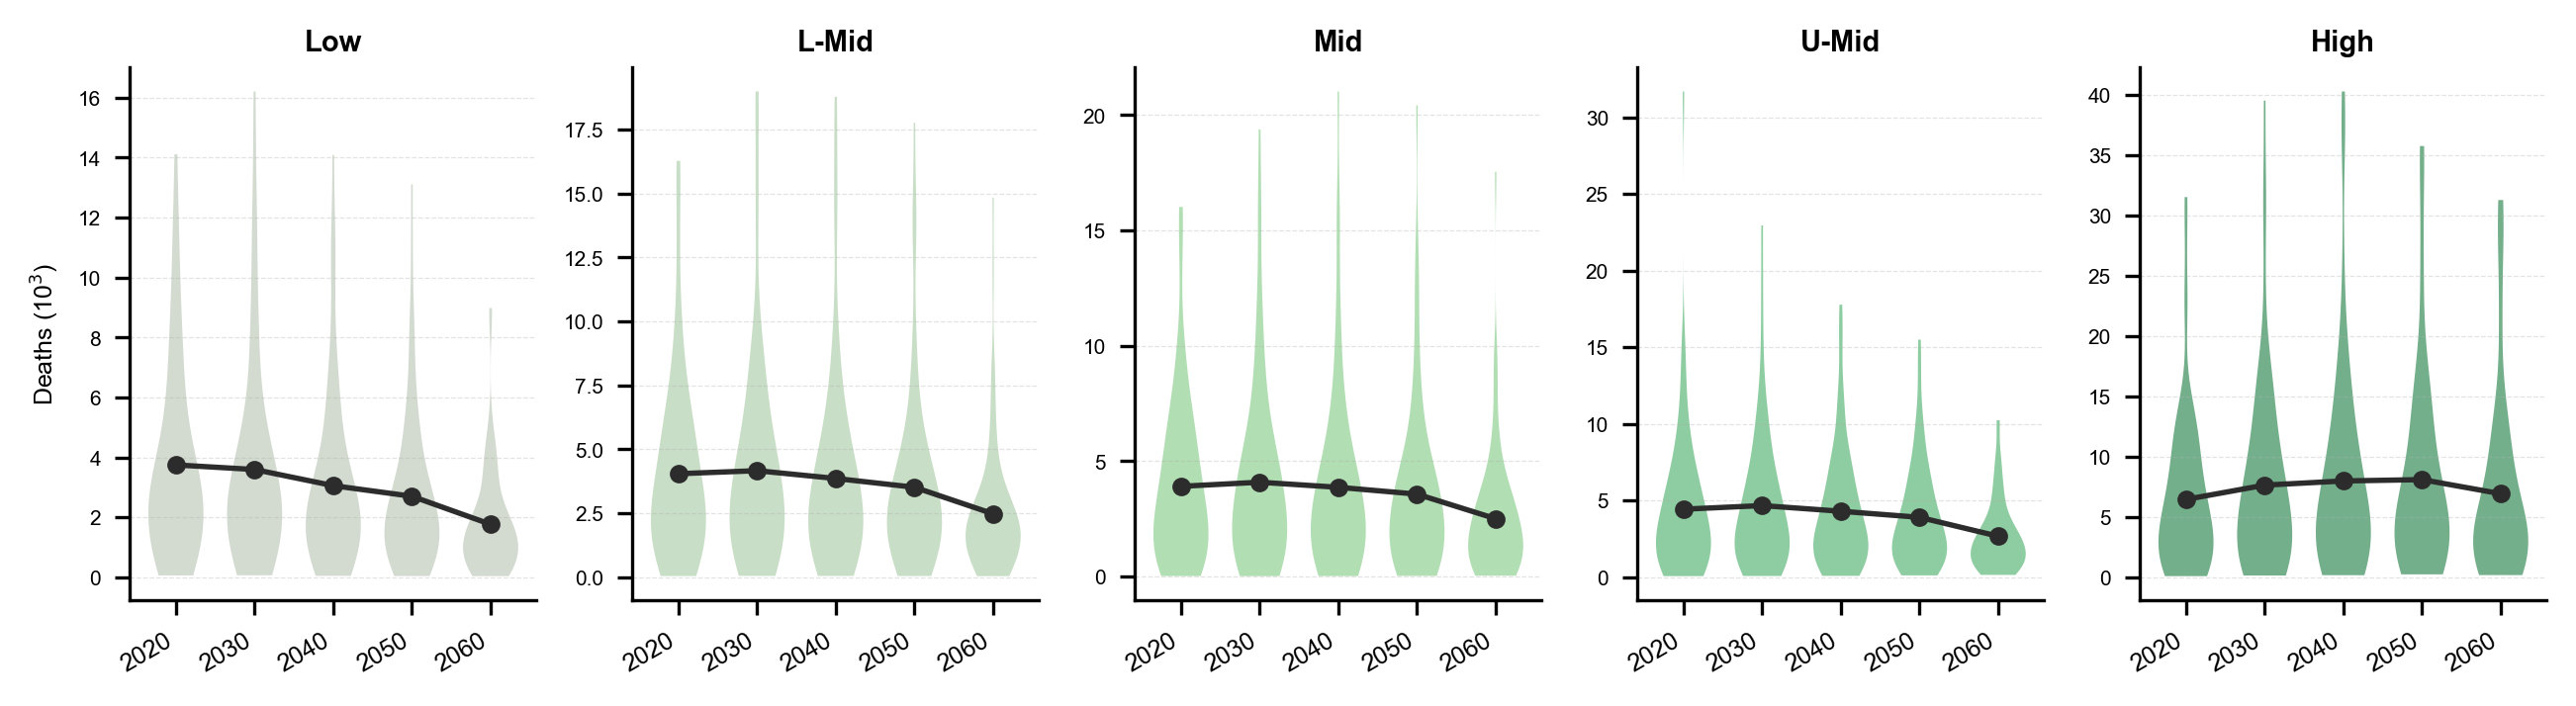

Saved → /Users/shirley/Desktop/plots_V2/FigS_death_income_violin.png


In [2]:
# =============================================================================
# NEW: Deaths by income group over time — violin plot per year, mean line connecting
# One subplot per income group (Low / L-Mid / Mid / U-Mid / High), x = year
# =============================================================================
YEARS = [2020, 2030, 2040, 2050, 2060]

def load_death_by_year(year):
    """City-level total deaths (mo_total, summed, /1000) for a given year."""
    return read_and_prep(DEATH_DIR, SCENARIO, year, DEATH_COL, f"d{year}", how="sum")

# --- build a long-format df: city, year, deaths(k), income_group ---
death_frames = []
for y in YEARS:
    df_y = load_death_by_year(y)
    df_y = df_y.rename(columns={f"d{y}": "deaths_k"})
    df_y["deaths_k"] = df_y["deaths_k"] / 1000
    df_y["year"] = y
    death_frames.append(df_y)

death_long = pd.concat(death_frames, ignore_index=True)

income_lookup = read_income_group(INCOME_DIR)  # SHP_CITY_FIELD, income_group
death_long = death_long.merge(income_lookup, on=SHP_CITY_FIELD, how="left")
death_long = death_long.dropna(subset=["income_group"])

# --- violin + mean-line plot, one panel per income group ---
def draw_income_death_violin(fig_width_cm=22, fig_height_cm=6):
    fig_v, axes_v = plt.subplots(
        1, len(INCOME_ORDER),
        figsize=(fig_width_cm / 2.54, fig_height_cm / 2.54),
        dpi=300, sharey=False
    )

    for ax, group in zip(axes_v, INCOME_ORDER):
        sub = death_long[death_long["income_group"] == group]

        # data per year, in YEARS order, dropping any empty years
        data_per_year = [sub.loc[sub["year"] == y, "deaths_k"].values for y in YEARS]
        positions = np.arange(len(YEARS))

        vp = ax.violinplot(
            data_per_year, positions=positions,
            widths=0.7, showmeans=False, showmedians=False, showextrema=False
        )
        for body in vp["bodies"]:
            body.set_facecolor(INCOME_COLORS[group])
            body.set_edgecolor("none")
            body.set_alpha(0.55)

        # mean per year, connected by line
        means = [d.mean() if len(d) > 0 else np.nan for d in data_per_year]
        ax.plot(positions, means, color="#2c2c2c", lw=1.3, marker="o",
                 markersize=3.5, zorder=5)

        ax.set_xticks(positions)
        ax.set_xticklabels([str(y) for y in YEARS], fontsize=FS_BASE, rotation=30, ha="right")
        ax.set_title(INCOME_SHORT[group], fontsize=FS_BASE + 1, fontweight="bold", pad=4)
        ax.spines[["top", "right"]].set_visible(False)
        ax.tick_params(axis="y", labelsize=FS_SCALE)
        ax.grid(axis="y", lw=0.3, alpha=0.35, linestyle="--", zorder=0)

        if ax is axes_v[0]:
            ax.set_ylabel(r"Deaths (10$^{3}$)", fontsize=FS_BASE)

    fig_v.tight_layout()
    return fig_v

fig_violin = draw_income_death_violin()
VIOLIN_OUTFILE = OUTFILE.parent / "FigS_death_income_violin.png"
fig_violin.savefig(VIOLIN_OUTFILE, dpi=400, bbox_inches="tight", facecolor="white")
plt.show()
print(f"Saved → {VIOLIN_OUTFILE}")